In [22]:
import os
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# --------- Load data ---------
df = pd.read_csv(r"C:\Users\gjose\DSC630-T302\als_data.csv")

print("Shape:", df.shape)
display(df.head())

print("\nMissing values (top 10):")
display(df.isna().sum().sort_values(ascending=False).head(10))


Shape: (2223, 101)


,ID,Age_mean,Albumin_max,Albumin_median,Albumin_min,Albumin_range,ALSFRS_slope,ALSFRS_Total_max,ALSFRS_Total_median,ALSFRS_Total_min,...,Sodium_min,Sodium_range,SubjectID,trunk_max,trunk_median,trunk_min,trunk_range,Urine.Ph_max,Urine.Ph_median,Urine.Ph_min
0,1,65,57.0,40.5,38.0,0.066202,-0.965608,30,28.0,22,...,143.0,0.017422,533,8,7.0,7,0.002646,6.0,6.0,6.0
1,2,48,45.0,41.0,39.0,0.010453,-0.921717,37,33.0,21,...,136.0,0.010453,649,8,7.0,5,0.005386,7.0,5.0,5.0
2,3,38,50.0,47.0,45.0,0.008929,-0.914787,24,14.0,10,...,140.0,0.008929,1234,5,0.0,0,0.008929,6.0,5.0,5.0
3,4,63,47.0,44.0,41.0,0.012111,-0.598361,30,29.0,24,...,138.0,0.012469,2492,5,5.0,3,0.004988,7.0,6.0,5.0
4,5,63,47.0,45.5,42.0,0.008292,-0.444039,32,27.5,20,...,138.0,0.008292,2956,6,4.0,1,0.008489,6.0,5.0,5.0



Missing values (top 10):


ID                  0
leg_max             0
Platelets_max       0
onset_site_mean     0
onset_delta_mean    0
mouth_range         0
mouth_min           0
mouth_median        0
mouth_max           0
leg_range           0
dtype: int64

The dataset has anonymized ALS patient features. I’ll remove non-informative ID columns, handle missing data, scale features, and use K-means clustering. I’ll select the number of clusters using the silhouette score and visualize clusters using PCA.

In [50]:
# Drop the ID columns 
id_like = [c for c in df.columns if c.lower() in {"id", "subjectid"}]
print("Dropping ID-like columns:", id_like)

# Keep numeric columns only 
num_df = df.drop(columns=id_like).select_dtypes(include=[np.number])

print("Numeric shape:", num_df.shape)
display(num_df.head())



Dropping ID-like columns: ['ID', 'SubjectID']
Numeric shape: (2223, 100)


,Age_mean,Albumin_max,Albumin_median,Albumin_min,Albumin_range,ALSFRS_slope,ALSFRS_Total_max,ALSFRS_Total_median,ALSFRS_Total_min,ALSFRS_Total_range,...,Sodium_min,Sodium_range,trunk_max,trunk_median,trunk_min,trunk_range,Urine.Ph_max,Urine.Ph_median,Urine.Ph_min,cluster
0,65,57.0,40.5,38.0,0.066202,-0.965608,30,28.0,22,0.021164,...,143.0,0.017422,8,7.0,7,0.002646,6.0,6.0,6.0,1
1,48,45.0,41.0,39.0,0.010453,-0.921717,37,33.0,21,0.028725,...,136.0,0.010453,8,7.0,5,0.005386,7.0,5.0,5.0,1
2,38,50.0,47.0,45.0,0.008929,-0.914787,24,14.0,10,0.025000,...,140.0,0.008929,5,0.0,0,0.008929,6.0,5.0,5.0,0
3,63,47.0,44.0,41.0,0.012111,-0.598361,30,29.0,24,0.014963,...,138.0,0.012469,5,5.0,3,0.004988,7.0,6.0,5.0,1
4,63,47.0,45.5,42.0,0.008292,-0.444039,32,27.5,20,0.020374,...,138.0,0.008292,6,4.0,1,0.008489,6.0,5.0,5.0,0


In [26]:
# Replace missing values with median 
imputer = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(num_df)

# Standardize all features to zero mean / unit variance
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

print("Scaled array shape:", X_scaled.shape)


Scaled array shape: (2223, 99)


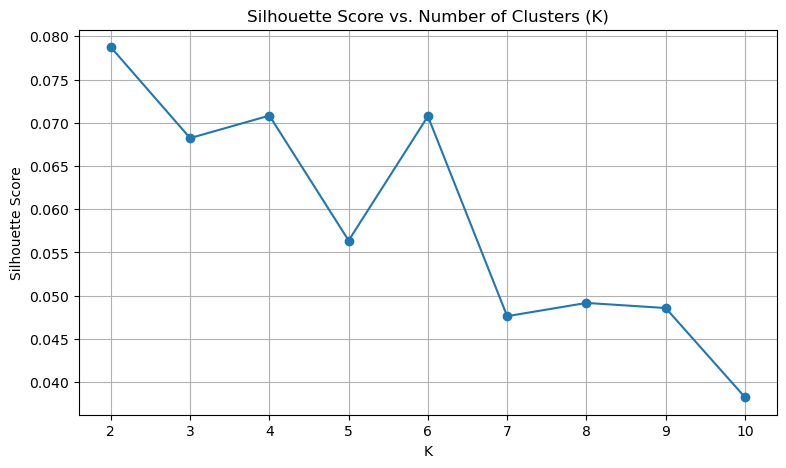

Best K by silhouette: 2 with score: 0.079


In [52]:
# Silence warnings 
import os, warnings

# Limit threads 
os.environ["OMP_NUM_THREADS"] = "1"   # 1–4 is fine; 1 is safest
os.environ["MKL_NUM_THREADS"] = "1"

# Silence sklearn warning 
warnings.filterwarnings(
    "ignore",
    message=r"KMeans is known to have a memory leak on Windows with MKL.*",
    category=UserWarning,
    module=r".*sklearn\.cluster\._kmeans"
)

# Silhouette analysis
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np
import matplotlib.pyplot as plt

Ks = range(2, 11)
scores = []

for k in Ks:
    kmeans = KMeans(n_clusters=k, n_init=10, algorithm="lloyd", random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    scores.append(score)

# Plot silhouette vs K
plt.figure(figsize=(9, 5))
plt.plot(list(Ks), scores, marker="o")
plt.title("Silhouette Score vs. Number of Clusters (K)")
plt.xlabel("K")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

# Choose best K
best_k = Ks[int(np.argmax(scores))]
print(f"Best K by silhouette: {best_k} with score: {max(scores):.3f}")



In [54]:
# Fit final KMeans with the best_k = 2
kmeans_final = KMeans(n_clusters=best_k, n_init=10, algorithm="lloyd", random_state=42)
cluster_labels = kmeans_final.fit_predict(X_scaled)

# Add cluster labels back to the dataframe
df["cluster"] = cluster_labels

print("Cluster sizes:")
print(df["cluster"].value_counts())


Cluster sizes:
cluster
1    1112
0    1111
Name: count, dtype: int64


In [56]:
from sklearn.decomposition import PCA

# Reduce dimensions to 2 for visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Put PCA components into a DataFrame
pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["cluster"] = cluster_labels

print("Explained variance ratio:", pca.explained_variance_ratio_)
pca_df.head()


Explained variance ratio: [0.11330548 0.06446616]


,PC1,PC2,cluster
0,1.426731,-2.319374,1
1,1.440235,-4.871672,1
2,-1.617855,-0.429015,0
3,1.919998,2.095630,1
4,-0.297704,0.167252,0


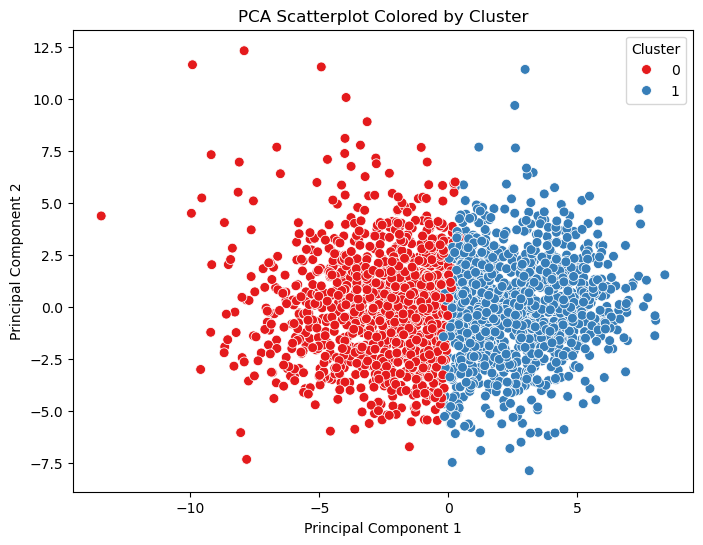

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="cluster", palette="Set1", s=50)
plt.title("PCA Scatterplot Colored by Cluster")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.show()


**Summary:**

I analyzed the ALS data to see if the patients could be grouped into meaningful clusters. 
First, I removed ID numbers that don’t describe the patient’s condition. 
I then filled in missing values using the middle value for each column and adjusted all the measurements so they were on the same scale. 

Next, I tested different numbers of groups from 2 to 10 using a measure called the silhouette score, 
which tells us how clearly the groups are separated. The scores were low overall, meaning the groups are not very strong, 
but the best result came when I divided the patients into 2 groups. 

I then used the PCA method to shrink the data down to two main dimensions so I could make a simple picture. 
The scatterplot shows two groups, but they are only weakly separated.

**Conclusion:**  
The analysis shows there are two broad groups of patients in this dataset, but since the groups are not very different from each other, we should be careful about how much we trust these results.
This clustering is a starting point, but more detailed analysis and clinical knowledge are needed 
to understand if these groups truly reflect differences in ALS progression.

